<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Evidencia 19-03
#### Kala Ariadna Guevara


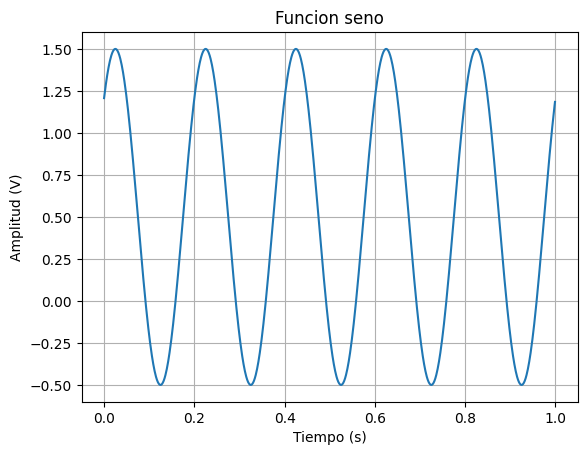

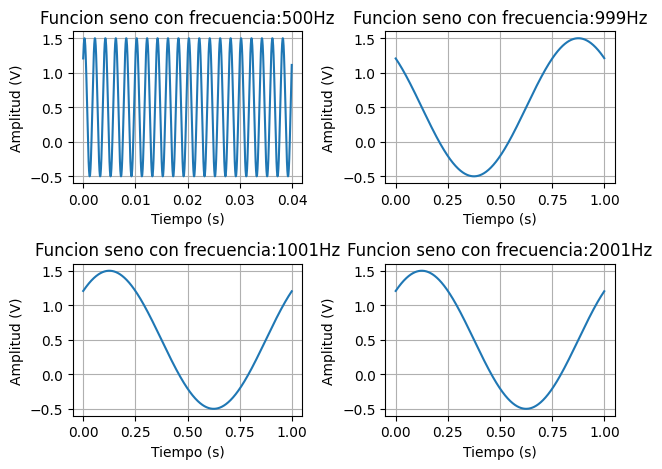

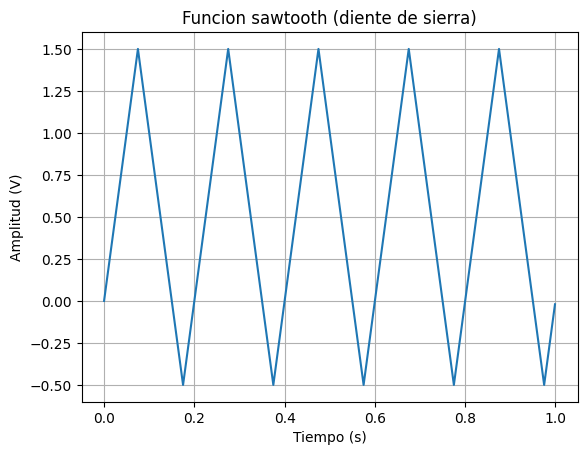

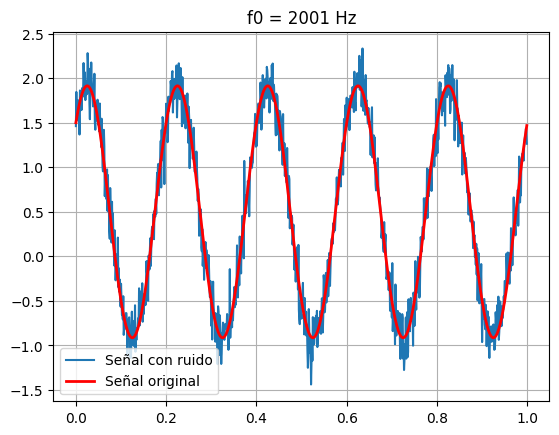

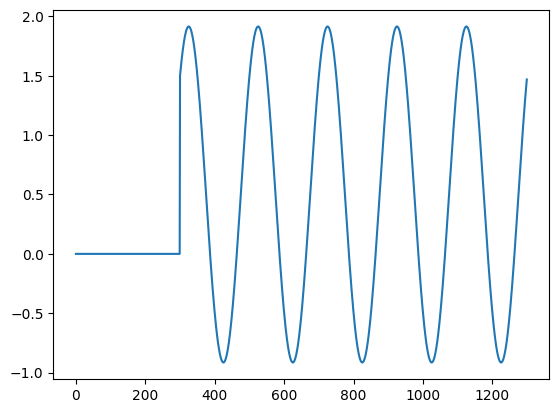

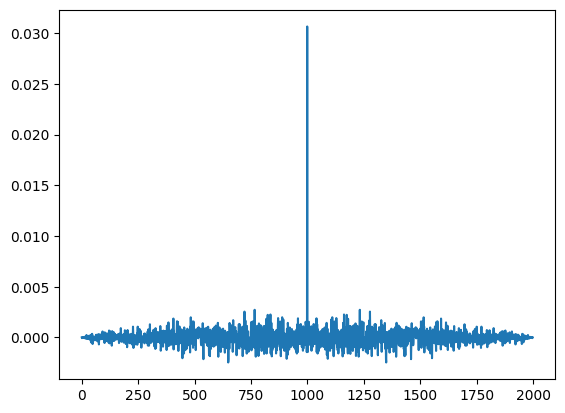

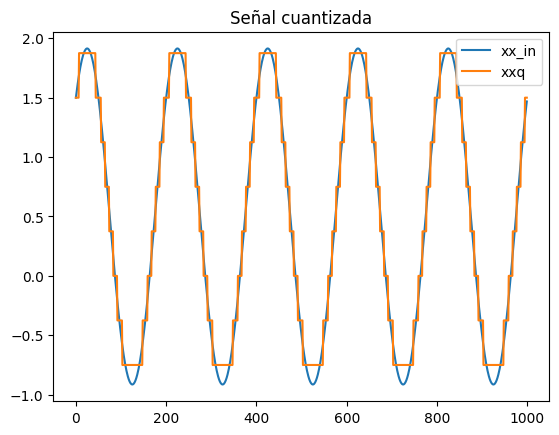

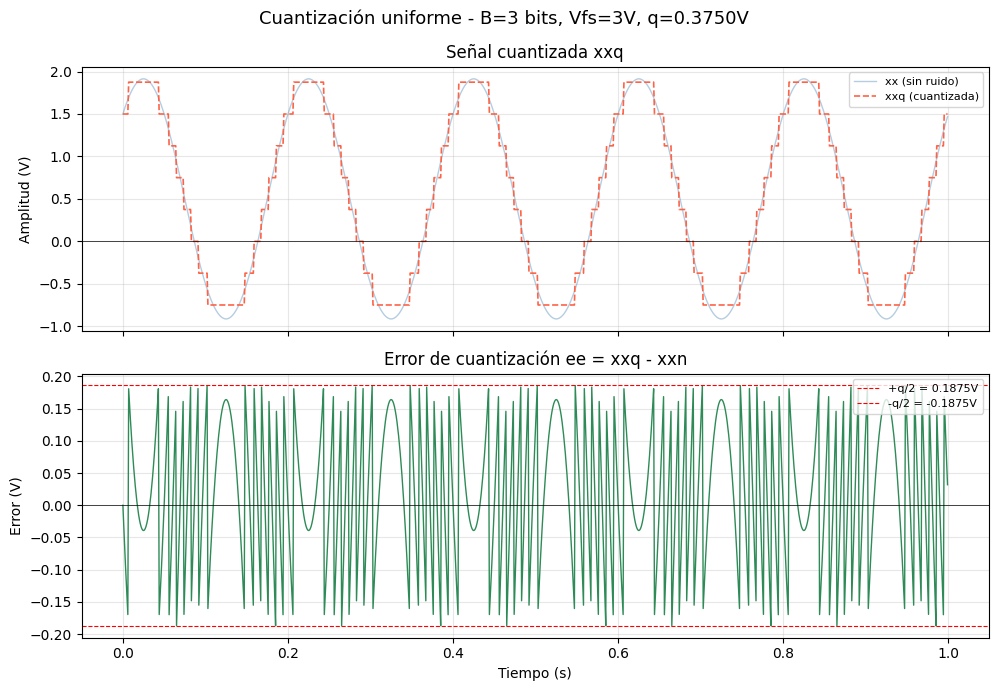

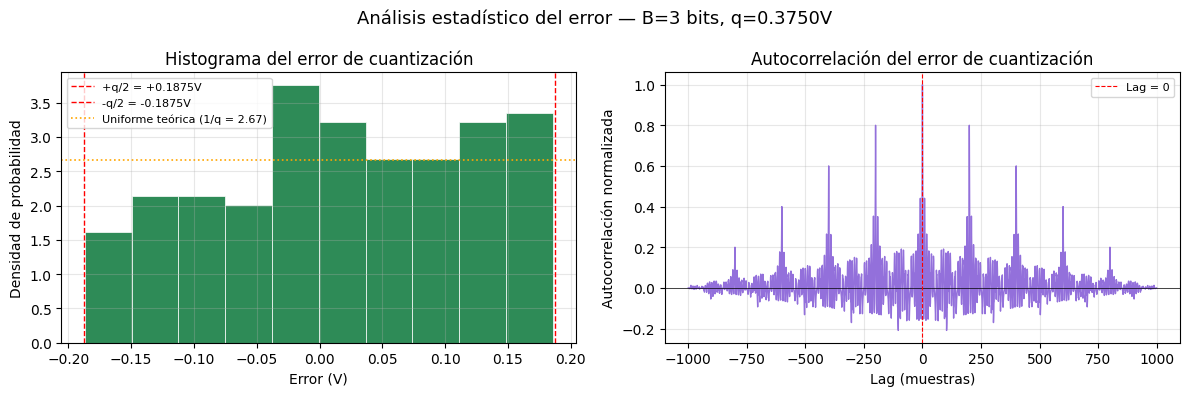

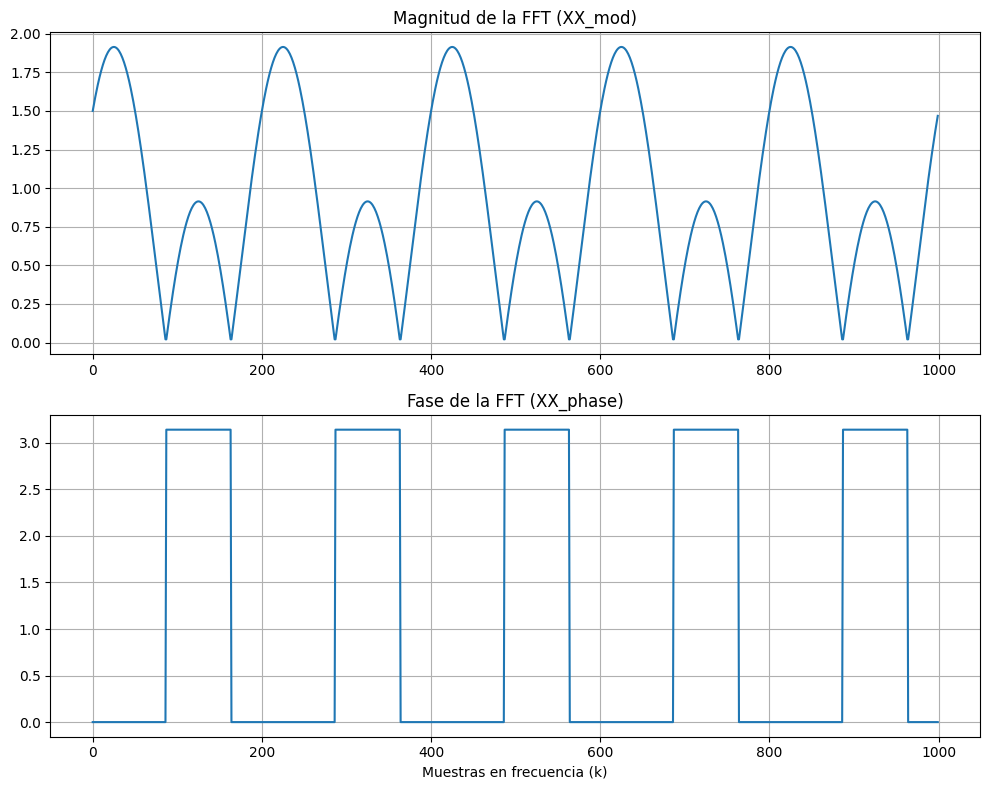

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Aug 13 18:56:16 2025

@author: gueva
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

#%%
#Ejecicio TP0
def funcion_seno(amp, desplazo, frec, fase, cant_muestras, frec_muestreo):
    # Crear el vector de tiempos
    tt = (np.arange(cant_muestras)/frec_muestreo).reshape(-1, 1)
    
    # Calcular la señal senoidal
    xx = (amp * np.sin(2 * np.pi * frec * tt + fase) + desplazo).reshape(-1, 1)
    return tt, xx
    
    # Generar señal
tt, xx = funcion_seno(amp=1, desplazo=0.5, frec=5, fase=np.pi/4, cant_muestras=1000, frec_muestreo=1000)
    
    # Graficar
plt.figure(1)
plt.plot(tt, xx)
plt.title('Funcion seno')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.show()

#%%
#Bonus: Experimento con frecuencias vistas en clase:
lista_frec_experimento = [500,999,1001,2001]
plt.figure(2)
for i in range(len(lista_frec_experimento)):
    frec = lista_frec_experimento[i]
    if (frec == 500):
        tt, xx = funcion_seno(amp=1, desplazo=0.5, frec=frec, fase=np.pi/4, cant_muestras=1000, frec_muestreo=25000)
        plt.subplot(2, 2, i+1)  
        plt.plot(tt, xx)
        plt.title(f'Funcion seno con frecuencia:{frec}Hz')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (V)')
        plt.grid(True)
    else:
        tt, xx = funcion_seno(amp=1, desplazo=0.5, frec=frec, fase=np.pi/4, cant_muestras=1000, frec_muestreo=1000)
        plt.subplot(2, 2, i+1)  
        plt.plot(tt, xx)
        plt.title(f'Funcion seno con frecuencia:{frec}Hz')
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Amplitud (V)')
        plt.grid(True)

plt.tight_layout()
plt.show()

#%%
#Bonus: Experimentar con otra funcion:
def generar_sawtooth(amp, desplazo, frec, fase, cant_muestras, frec_muestreo, width):
    # Vector de tiempos con arange
    tt = (np.arange(cant_muestras)/frec_muestreo).reshape(-1, 1)
    
    # Generar señal sawtooth
    xx = (amp * signal.sawtooth(2 * np.pi * frec * tt + fase, width=width) + desplazo).reshape(-1, 1)
    return tt, xx

    # Generar señal
tt, xx = generar_sawtooth(amp=1, desplazo=0.5, frec=5, fase=np.pi/4, cant_muestras=1000, frec_muestreo=1000, width=0.5)
     
    # Graficar
plt.figure(3)
plt.plot(tt, xx)
plt.title('Funcion sawtooth (diente de sierra)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.grid(True)
plt.show()

#%%
#potencia de señal
vmax=np.sqrt(2)
tt, xx = funcion_seno(vmax, 0.5, 5, np.pi/4, 1000, 1000)
Px = np.var(xx)

SNR = 15

Pr = 1/(10**(SNR/10)) #en clase lo puse disitno estaba mal

#agrego esto porque sino me tira error, falta variables en random normal
mu = 0
n = len(xx)  

#el ruido
U_n = np.random.normal(mu, np.sqrt(Pr), n).reshape(-1,1)
#le puse reshape porque me tiraba error con las dimensiones

#señal mas ruido
xxn = xx + U_n

#tuqui grafico
plt.figure(4)
plt.clf()
plt.plot(tt, xxn, label='Señal con ruido')
plt.plot(tt, xx, 'r', lw=2, label='Señal original')
plt.title(f'f0 = {frec} Hz')
plt.legend()
plt.grid(True)
plt.show()

#%%
from scipy import signal as sig
n0 = 300   #muestras

dd = np.zeros(n0+1)
dd[n0] = 1

yy = sig.convolve(xx.flatten(), dd) #tmb me tiraba error con dimensiones

plt.figure(5)
plt.clf()
plt.plot(yy)


#%%
yy = 1/n * sig.convolve(U_n, np.flip(U_n))

plt.figure(6)
plt.clf()
plt.plot(yy)

#%%
B = 3  # bits
Vfs = 3  # Volts

qq = Vfs / 2**B

xx_in = xx
#xx_in = xxn

xxq = np.round(xx_in / qq) * qq
ee = xxq - xx_in

plt.figure(4)
plt.clf()
plt.plot(xx_in, label='xx_in')
plt.plot(xxq, label='xxq')
plt.legend()
plt.title('Señal cuantizada')

#%%
# --- Autocorrelación ---
ee = ee.flatten() #me tiraba error xq lo estaba haciendo 2dy no 1d
autocorr_full = np.correlate(ee, ee, mode='full')
autocorr = autocorr_full / np.max(np.abs(autocorr_full))
lags = np.arange(-len(ee) + 1, len(ee))

#%%
# --- Graficación con subplots
fig, (ax2, ax3) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f'Cuantización uniforme - B={B} bits, Vfs={Vfs}V, q={qq:.4f}V', fontsize=13)

# Subplot 2: señal cuantizada
ax2.plot(tt, xx_in, color='steelblue', linewidth=1, alpha=0.4, label='xx (sin ruido)')
ax2.plot(tt, xxq, color='tomato', linewidth=1.2, linestyle='--', label='xxq (cuantizada)')
ax2.set_ylabel('Amplitud (V)')
ax2.set_title('Señal cuantizada xxq')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5)

# Subplot 3: error de cuantización
ax3.plot(tt, ee, color='seagreen', linewidth=1)
ax3.axhline(qq/2, color='red', linewidth=0.8, linestyle='--', label=f'+q/2 = {qq/2:.4f}V')
ax3.axhline(-qq/2, color='red', linewidth=0.8, linestyle='--', label=f'-q/2 = {-qq/2:.4f}V')
ax3.set_ylabel('Error (V)')
ax3.set_xlabel('Tiempo (s)')
ax3.set_title('Error de cuantización ee = xxq - xxn')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()
#%%
# --- Figura 2: histograma + autocorrelación ---
fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle(f'Análisis estadístico del error — B={B} bits, q={qq:.4f}V', fontsize=13)

# Histograma
n_bins = 10
ax4.hist(ee, bins=n_bins, color='seagreen', edgecolor='white', linewidth=0.5, density=True)
ax4.axvline( qq/2, color='red', linewidth=1, linestyle='--', label=f'+q/2 = +{qq/2:.4f}V')
ax4.axvline(-qq/2, color='red', linewidth=1, linestyle='--', label=f'-q/2 = -{qq/2:.4f}V')

# Densidad uniforme teórica
ax4.axhline(1/qq, color='orange', linewidth=1.2, linestyle=':', label=f'Uniforme teórica (1/q = {1/qq:.2f})')
ax4.set_xlabel('Error (V)')
ax4.set_ylabel('Densidad de probabilidad')
ax4.set_title('Histograma del error de cuantización')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# Autocorrelación
# max_lag = 100
# max_lag = n
# lag_range = slice(len(ee) - 1 - max_lag, len(ee) + max_lag)
ax5.plot(lags, autocorr, color='mediumpurple', linewidth=1)
ax5.axhline(0, color='black', linewidth=0.5)
ax5.axvline(0, color='red', linewidth=0.8, linestyle='--', label='Lag = 0')
ax5.set_xlabel('Lag (muestras)')
ax5.set_ylabel('Autocorrelación normalizada')
ax5.set_title('Autocorrelación del error de cuantización')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#%%
# --- FFT---
XX = np.fft.fft(xx)
XX_mod = np.abs(XX)
XX_phase = np.angle(XX)

# --- GRÁFICO ---
plt.figure(figsize=(10, 8))

# Subplot 1: Magnitud
plt.subplot(2, 1, 1)
plt.plot(XX_mod)
plt.title('Magnitud de la FFT (XX_mod)')
plt.grid(True)

# Subplot 2: Fase
plt.subplot(2, 1, 2)
plt.plot(XX_phase)
plt.title('Fase de la FFT (XX_phase)')
plt.xlabel('Muestras en frecuencia (k)')
plt.grid(True)

plt.tight_layout()
plt.show()